In [41]:
import pandas as pd
import numpy as np
from faker import Faker
import random

In [42]:
fake = Faker()

In [43]:
occupations = [
  'Software Engineer', 'Teacher', 'Doctor', 'Nurse', 'Accountant', 'Salesperson',
    'Manager', 'Driver', 'Clerk', 'Electrician', 'Mechanic', 'Chef', 'Artist',
    'Scientist', 'Lawyer', 'Police Officer', 'Pharmacist', 'Consultant', 'Analyst', 'Farmer'
]

def generate_row_with_nulls():
  age = random.randint(15,60)
  income = random.randint(15000,100000)
  max_budget = min(income,200000)
  min_budget = 50000

  if max_budget < min_budget:
    budget = max_budget
  else:
    budget = random.randint(min_budget,max_budget)
  ph_no = fake.phone_number()if np.random.rand() > 0.1 else None
  mail_id = fake.email()if np.random.rand() > 0.1 else None
  rented_house = random.choice(['Yes','No'])
  insurance =  random.choice(['Yes','No'])
  occupation = random.choice(occupations)

  return [age,income,budget,ph_no,mail_id,rented_house,insurance,occupation]

num_rows = 10000

data = [generate_row_with_nulls() for _ in range(num_rows)]

columns = ['age','income','budget','ph_no','mail_id','rented_house','insurance','occupation']

df = pd.DataFrame(data,columns = columns)




In [44]:
df.shape

(10000, 8)

In [45]:
df.head()

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
0,16,66594,52143,None,linda06@example.com,Yes,No,Clerk
1,37,76034,53317,409-266-6848,tammiewilliams@example.net,No,No,Mechanic
2,49,20689,20689,(564)432-4756,rodney74@example.com,Yes,No,Police Officer
3,29,59970,52535,+1-976-497-3364x9152,zsmith@example.com,No,No,Salesperson
4,16,84711,65173,748.373.3507x029,jeromejohnson@example.com,Yes,Yes,Farmer


In [46]:
df.tail()

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
9995,36,80861,64615,None,None,Yes,No,Clerk
9996,60,49238,49238,650.854.8903x6395,calderonrebecca@example.net,Yes,No,Pharmacist
9997,17,91904,70472,None,williamsonsharon@example.org,No,Yes,Accountant
9998,58,55043,52634,404-254-6668x124,theresacannon@example.com,No,No,Farmer
9999,53,64522,56656,+1-226-554-3785x3686,lmyers@example.com,Yes,No,Salesperson


In [47]:
df.info

<bound method DataFrame.info of       age  income  budget                 ph_no                       mail_id  \
0      16   66594   52143                  None           linda06@example.com   
1      37   76034   53317          409-266-6848    tammiewilliams@example.net   
2      49   20689   20689         (564)432-4756          rodney74@example.com   
3      29   59970   52535  +1-976-497-3364x9152            zsmith@example.com   
4      16   84711   65173      748.373.3507x029     jeromejohnson@example.com   
...   ...     ...     ...                   ...                           ...   
9995   36   80861   64615                  None                          None   
9996   60   49238   49238     650.854.8903x6395   calderonrebecca@example.net   
9997   17   91904   70472                  None  williamsonsharon@example.org   
9998   58   55043   52634      404-254-6668x124     theresacannon@example.com   
9999   53   64522   56656  +1-226-554-3785x3686            lmyers@example.com

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           10000 non-null  int64 
 1   income        10000 non-null  int64 
 2   budget        10000 non-null  int64 
 3   ph_no         9006 non-null   object
 4   mail_id       8963 non-null   object
 5   rented_house  10000 non-null  object
 6   insurance     10000 non-null  object
 7   occupation    10000 non-null  object
dtypes: int64(3), object(5)
memory usage: 625.1+ KB


In [49]:
df.describe()

,age,income,budget
count,10000.000000,10000.000000,10000.000000
mean,37.565900,57592.350900,50120.752900
std,13.319962,24644.484393,18251.029555
min,15.000000,15008.000000,15008.000000
25%,26.000000,36384.000000,36384.000000
50%,38.000000,57750.500000,51810.000000
75%,49.000000,78778.000000,61718.750000
max,60.000000,99999.000000,99562.000000


In [50]:
df.isna().sum()

age                0
income             0
budget             0
ph_no            994
mail_id         1037
rented_house       0
insurance          0
occupation         0
dtype: int64

In [51]:
df_cleaned = df.dropna(subset=['ph_no']).copy()

In [52]:
df_cleaned.shape

(9006, 8)

In [53]:
df_cleaned.isna().sum()

age               0
income            0
budget            0
ph_no             0
mail_id         936
rented_house      0
insurance         0
occupation        0
dtype: int64

In [54]:
df_cleaned['mail_id'] = df_cleaned['mail_id'].fillna('unknown')

In [55]:
df_cleaned.isna().sum()

age             0
income          0
budget          0
ph_no           0
mail_id         0
rented_house    0
insurance       0
occupation      0
dtype: int64

In [56]:
df_cleaned['mail_id'].value_counts()

mail_id
unknown                        936
lisa73@example.org               3
ubrown@example.com               3
esmith@example.net               3
mwilliams@example.com            3
                              ... 
ethanhaynes@example.net          1
andrea04@example.com             1
calderonrebecca@example.net      1
theresacannon@example.com        1
santiagoeric@example.com         1
Name: count, Length: 7921, dtype: int64

In [57]:
df_cleaned.head()

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
1,37,76034,53317,409-266-6848,tammiewilliams@example.net,No,No,Mechanic
2,49,20689,20689,(564)432-4756,rodney74@example.com,Yes,No,Police Officer
3,29,59970,52535,+1-976-497-3364x9152,zsmith@example.com,No,No,Salesperson
4,16,84711,65173,748.373.3507x029,jeromejohnson@example.com,Yes,Yes,Farmer
5,56,71357,66830,001-712-239-3075x4959,hsmith@example.net,Yes,Yes,Doctor


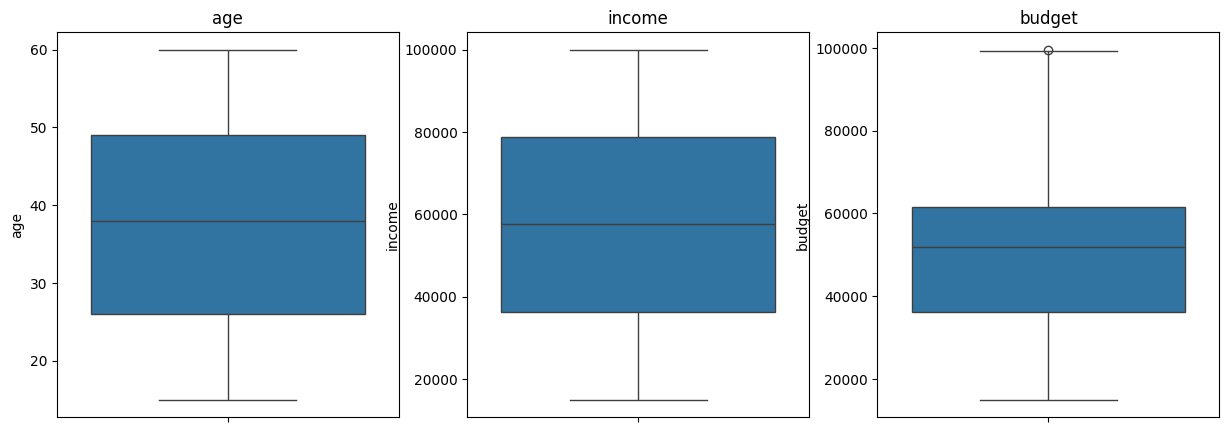

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y = df_cleaned['age'])
plt.title('age')

plt.subplot(1,3,2)
sns.boxplot(y = df_cleaned['income'])
plt.title('income')


plt.subplot(1,3,3)
sns.boxplot(y = df_cleaned['budget'])
plt.title('budget')

plt.show()


In [59]:
df_cleaned.describe(include='all')

,age,income,budget,ph_no,mail_id,rented_house,insurance,occupation
count,9006.000000,9006.000000,9006.000000,9006,9006,9006,9006,9006
unique,NaN,NaN,NaN,9006,7921,2,2,20
top,NaN,NaN,NaN,+1-226-554-3785x3686,unknown,Yes,Yes,Lawyer
freq,NaN,NaN,NaN,1,936,4561,4584,516
mean,37.585499,57487.005219,50004.554519,NaN,NaN,NaN,NaN,NaN
std,13.321463,24696.847110,18261.781528,NaN,NaN,NaN,NaN,NaN
min,15.000000,15008.000000,15008.000000,NaN,NaN,NaN,NaN,NaN
25%,26.000000,36285.000000,36285.000000,NaN,NaN,NaN,NaN,NaN
50%,38.000000,57580.500000,51772.000000,NaN,NaN,NaN,NaN,NaN
75%,49.000000,78772.750000,61526.250000,NaN,NaN,NaN,NaN,NaN


In [60]:
df_for_clustering = df_cleaned[['age', 'income', 'budget', 'rented_house', 'insurance', 'occupation']]

In [61]:
df_for_clustering.head()

,age,income,budget,rented_house,insurance,occupation
1,37,76034,53317,No,No,Mechanic
2,49,20689,20689,Yes,No,Police Officer
3,29,59970,52535,No,No,Salesperson
4,16,84711,65173,Yes,Yes,Farmer
5,56,71357,66830,Yes,Yes,Doctor


In [65]:
df_for_clustering.isna().sum()

age             0
income          0
budget          0
rented_house    0
insurance       0
occupation      0
cluster         0
dtype: int64

In [62]:
df_for_clustering.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9006 entries, 1 to 9999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           9006 non-null   int64 
 1   income        9006 non-null   int64 
 2   budget        9006 non-null   int64 
 3   rented_house  9006 non-null   object
 4   insurance     9006 non-null   object
 5   occupation    9006 non-null   object
dtypes: int64(3), object(3)
memory usage: 492.5+ KB


In [66]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 3, random_state = 42)
kmeans.fit(df_for_clustering[['age', 'income', 'budget']])
df_for_clustering['cluster'] = kmeans.labels_


C:\Users\DELL\AppData\Local\Temp\ipykernel_11384\1344914568.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_for_clustering['cluster'] = kmeans.labels_


In [67]:
type(df_for_clustering)

pandas.core.frame.DataFrame

In [ ]:
df_cleaned_with_clusters = df_for_clustering.copy()

In [69]:
df_cleaned_with_clusters["cluster_with_num_cols_only"] = kmeans.labels_

In [73]:
df_cleaned_with_clusters.head()  

,age,income,budget,rented_house,insurance,occupation,cluster,cluster_with_num_cols_only
1,37,76034,53317,No,No,Mechanic,1,1
2,49,20689,20689,Yes,No,Police Officer,2,2
3,29,59970,52535,No,No,Salesperson,0,0
4,16,84711,65173,Yes,Yes,Farmer,1,1
5,56,71357,66830,Yes,Yes,Doctor,1,1


In [74]:
df_cleaned_with_clusters['cluster_with_num_cols_only'].value_counts()

cluster_with_num_cols_only
0    3186
1    3104
2    2716
Name: count, dtype: int64

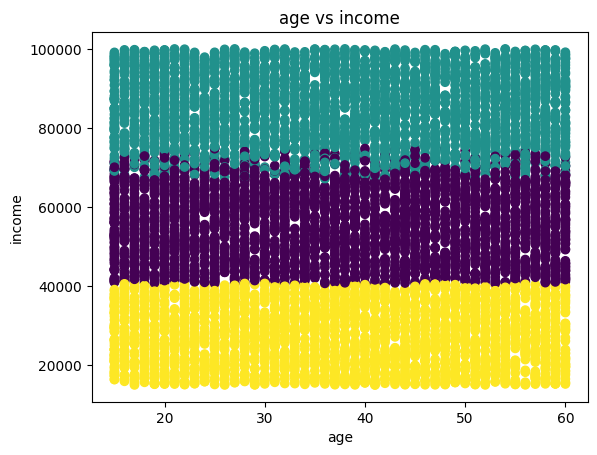

In [75]:
plt.scatter(df_cleaned_with_clusters['age'],df_cleaned_with_clusters['income'],c =df_cleaned_with_clusters['cluster_with_num_cols_only'],cmap = 'viridis')
plt.xlabel('age')
plt.ylabel('income')
plt.title('age vs income')
plt.show()